/public/home/rastus/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


['7', '2', '3', '6', '4', '5', '8']
Processing image: 7.png


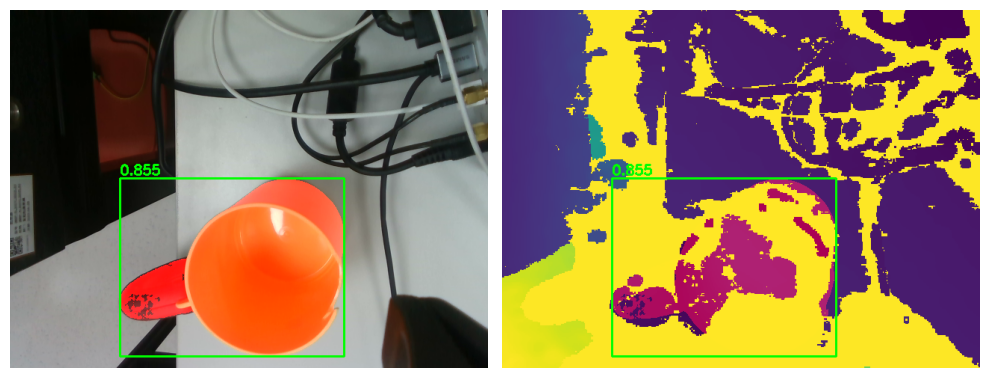

最近点深度： 0.215
单帧原始点云数量: 18024 
 
Remove statistical outliers: [=>                                      ] 2%
 单帧过滤后点云数量: 6294
(4, 4) (4, 6294)al outliers: [=======================================>] 97%
Processing image: 2.png


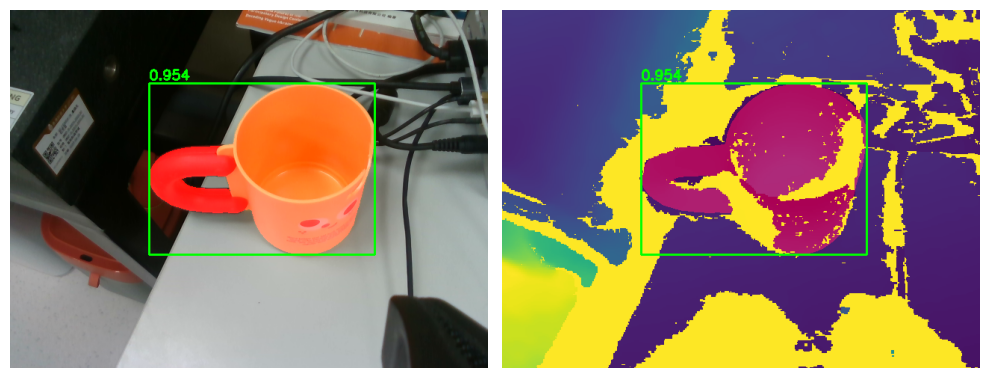

最近点深度： 0.243
单帧原始点云数量: 33117 
 
Remove statistical outliers: [========================================] 100%
Remove statistical outliers: [=======================================>] 97%
 单帧过滤后点云数量: 13346
(4, 4) (4, 13346)
Processing image: 3.png


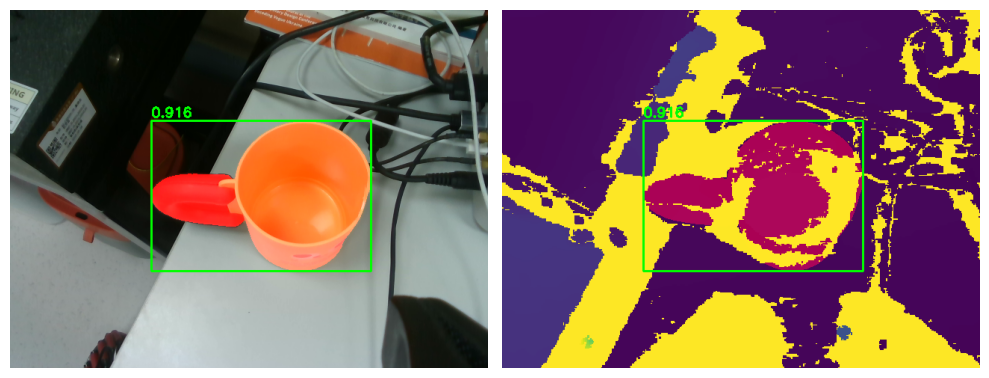

最近点深度： 0.259
单帧原始点云数量: 23338 
 
Remove statistical outliers: [========================================] 100%
Remove statistical outliers: [============>                           ] 30%
 单帧过滤后点云数量: 9754
(4, 4) (4, 9754)al outliers: [=======================================>] 97%
Processing image: 6.png


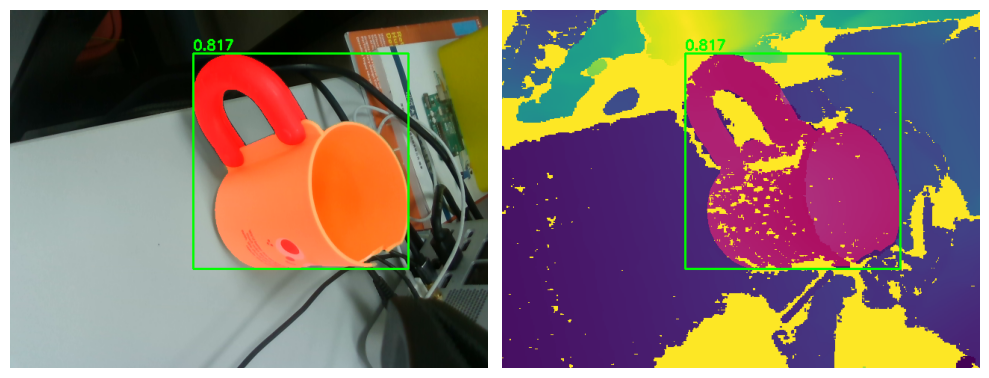

最近点深度： 0.224
单帧原始点云数量: 48207 
 
Remove statistical outliers: [========================================] 100%
Remove statistical outliers: [============>                           ] 30%
 单帧过滤后点云数量: 17085
(4, 4) (4, 17085)l outliers: [=======================================>] 97%
Processing image: 4.png


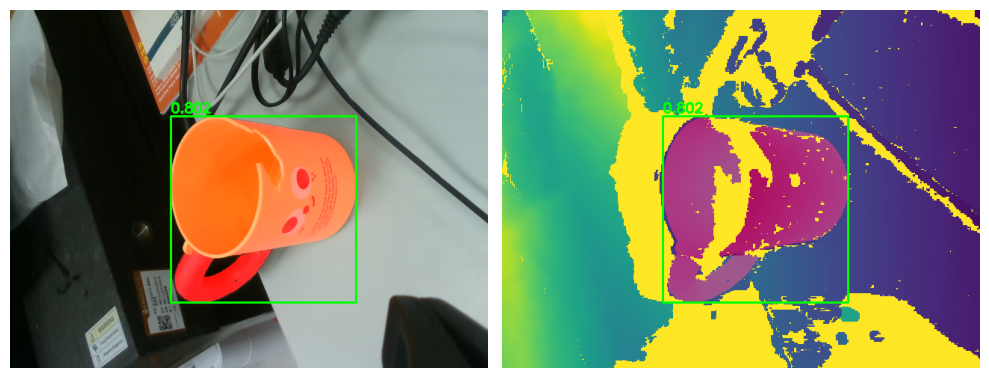

最近点深度： 0.232
单帧原始点云数量: 34075 
 
Remove statistical outliers: [========================================] 100%
Remove statistical outliers: [=======================================>] 97%
 单帧过滤后点云数量: 13511
(4, 4) (4, 13511)
Processing image: 5.png


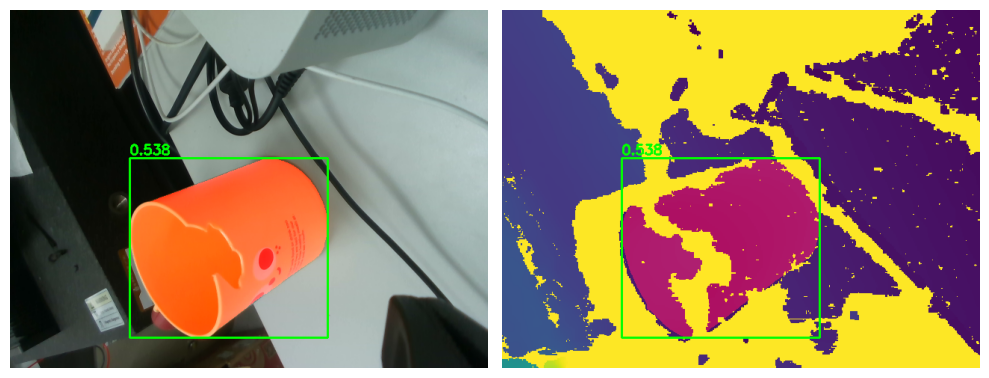

最近点深度： 0.221
单帧原始点云数量: 33481 
 
Remove statistical outliers: [========================================] 100%
Remove statistical outliers: [=======================================>] 97%
 单帧过滤后点云数量: 10480
(4, 4) (4, 10480)
Processing image: 8.png


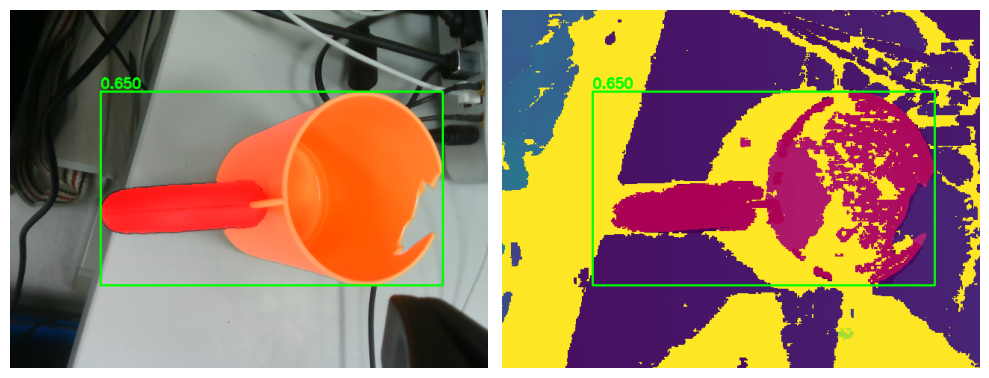

最近点深度： 0.167
单帧原始点云数量: 41014 
 
Remove statistical outliers: [========================================] 100%
Remove statistical outliers: [=======================================>] 97%
 单帧过滤后点云数量: 9851
(4, 4) (4, 9851)


In [1]:
from scipy.spatial.transform import Rotation as R
import os, torch, gc, json, cv2, sys
sys.path.append('/public/home/rastus/AAM')
import open3d as o3d
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from AI_models.LLM_funcitons import positioning

def load_camera_config(camera_config_path):
    config = np.load(camera_config_path, allow_pickle=True).item()
    depth_intrinsic = config['depth_intrinsic']
    color_intrinsic = config['color_intrinsic']
    depth_scale = config['depth_scale']
    depth_to_color_extrinsic = config['depth_to_color_extrinsic']

    return color_intrinsic, depth_intrinsic, depth_to_color_extrinsic, depth_scale

def mask_visualization(image_path, depth_path, mask, box, score):
    # 1. 加载RGB
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

    # 2. 加载深度图 & 转伪彩色
    depth = np.nan_to_num(np.load(depth_path), nan=0.0, posinf=0.0, neginf=0.0)
    valid = depth[depth > 0]
    if len(valid) == 0: valid = [0, 1]  # 防空数组报错保底
    d_min, d_max = valid.min(), valid.max()
    d_range = d_max - d_min if d_max != d_min else 1.0

    depth_col = cv2.applyColorMap(np.clip((depth - d_min) / d_range * 255, 0, 255).astype(np.uint8), cv2.COLORMAP_VIRIDIS)
    depth_col = cv2.cvtColor(depth_col, cv2.COLOR_BGR2RGB)

    # 3. 创建Mask高亮层（仅mask区域有颜色，其余全0）
    mask_2d = np.squeeze(np.array(mask)) > 0
    highlight = np.zeros_like(img)
    highlight[mask_2d] = [255, 0, 0]  # 红色

    # 4. 透明叠加：addWeighted 会自动让非mask区域保持原图
    rgb_out = cv2.addWeighted(img, 1.0, highlight, 1, 0)
    depth_out = cv2.addWeighted(depth_col, 1.0, highlight, 0.4, 0)

    # 5. 绘制单框 + 分数
    x1, y1, x2, y2 = [int(v) for v in box[0]]
    for out in [rgb_out, depth_out]:
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(out, f"{score[0]:.3f}", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # 6. 显示
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.imshow(rgb_out); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(depth_out); plt.axis('off')
    plt.tight_layout(); plt.show()
    return

def end_to_base_transformationMatrix(endpose_path):
    with open(endpose_path, 'r', encoding='utf-8') as f:
        endpose = json.load(f)
    x = float(endpose[0]['x']) /1000000
    y = float(endpose[1]['y']) /1000000
    z = float(endpose[2]['z']) /1000000
    rx = float(endpose[3]['rx']) /1000
    ry = float(endpose[4]['ry']) /1000
    rz = float(endpose[5]['rz']) /1000
    rot = R.from_euler('xyz', [rx, ry, rz], degrees=True)
    beT_rot = rot.as_matrix() 
    beT = np.eye(4)
    beT[:3, :3] = beT_rot
    beT[:3, 3] = [x, y, z]
    
    return beT

def frame_pointcloud_generation(image_path,depth_path,endpose_path, config_path, ecT):
    depth = np.load(depth_path)
    img = cv2.imread(image_path)
    color_intrinsic,_,_,_ = load_camera_config(config_path)
    fx = color_intrinsic['fx']
    fy = color_intrinsic['fy']
    cx = color_intrinsic['ppx']
    cy = color_intrinsic['ppy']

    depth_scale = 1000.0
    mask, box, score = positioning(image_path,'cup')
    if len(score) > 1:
            max_score_idx = np.argmax(score)
            box = [box[max_score_idx]]
            mask = [mask[max_score_idx]]
            score = [score[max_score_idx]]  

    mask_visualization(image_path, depth_path, mask, box, score)
    mask = mask[0][0]
    # 确保深度图是 float32 并转换为米
    if depth.dtype == np.uint16:
        depth = depth.astype(np.float32) / depth_scale
    elif depth.dtype == np.uint8:
        depth = depth.astype(np.float32) * 0.01  # 假设是 0-255 -> 0-2.55m

    # 创建网格坐标 (u, v)
    H, W = depth.shape
    v_coords, u_coords = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')

    # 提取有效点的像素坐标和深度值
    min_depth, max_depth = 0.1, 0.8  
    depth_valid = (depth > min_depth) & (depth < max_depth)
    valid_mask = mask & depth_valid
    u_valid = u_coords[valid_mask]
    v_valid = v_coords[valid_mask]
    d_valid = depth[valid_mask]
    print('最近点深度：',np.min(d_valid))

    # 反投影到相机坐标系 (X, Y, Z)
    # 公式: X = (u - cx) * Z / fx, Y = (v - cy) * Z / fy, Z = d
    # fx, fy 是相机内参
    Z_cam = d_valid
    X_cam = (u_valid - cx) * Z_cam / fx
    Y_cam = (v_valid - cy) * Z_cam / fy
    points_cam = np.stack([X_cam, Y_cam, Z_cam], axis=1)  # shape: (N, 3)

    print(f"单帧原始点云数量: {points_cam.shape[0]} \n ")

    # 创建点云对象
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points_cam)

    if 'img' in locals() and 'v_valid' in locals():
        colors = img[v_valid, u_valid] / 255.0
        pcd.colors = o3d.utility.Vector3dVector(colors)
    
    # 体素化降采样
    pcd = pcd.voxel_down_sample(voxel_size=0.001)
    # 统计滤波（杯子场景优化参数）
    cl, ind = pcd.remove_statistical_outlier(
        nb_neighbors=50,      # 检查 个邻居
        std_ratio=1.0,        #  倍标准差阈值
        print_progress=True)
    # 获取过滤结果
    inlier_cloud = pcd.select_by_index(ind)
    cl, ind = inlier_cloud.remove_radius_outlier(
            nb_points=50,
            radius=0.015)

    points_cam = np.asarray(cl.points)
    print('\n 单帧过滤后点云数量:',points_cam.shape[0])
    points_cam = np.column_stack([points_cam, np.ones(len(points_cam))])
    
    beT = end_to_base_transformationMatrix(endpose_path)
    bcT = beT @ ecT
    print(bcT.shape, (points_cam.T).shape )
    points_base = bcT @points_cam.T
    points_base = points_base.T
    
    return points_base, bcT

def visualize_points(points):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)  # points 是 Nx3 的 numpy 数组
    o3d.visualization.draw_geometries([pcd])
    return


torch.cuda.empty_cache()
gc.collect()
folder_path = Path(r"/public/home/rastus/AAM/construction/result")
png_files = list(folder_path.glob('*.png'))
png_names = [p.stem for p in png_files] # p.name 仅获取文件名，不含路径
points_collection = []
bcT_collection = []
print(png_names)

ecT = np.array([[0,0.9397,0.342,-0.0737],
    [-1,0,0,0.044],
    [0,-0.342,0.9397,0.0493],
    [0,0,0,1]], dtype=np.float64)

for name in png_names:
    print(f'Processing image: {name}.png')
    image_path =   str(folder_path) + '/'+ name + '.png'
    depth_path =   str(folder_path) + '/'+ name + '.npy'
    endpose_path = str(folder_path) + '/'+ name + '.json'
    config_path =  '/public/home/rastus/AAM'+ '/perception/result/1st_capturing/camera_config.npy'  # os.getcwd()
    points, bcT = frame_pointcloud_generation(image_path,depth_path,endpose_path, config_path, ecT)
    points_collection.append(points)
    bcT_collection.append(bcT)


### 刚性变换配准结果

In [2]:
chosen_frame_points = [ points_collection[1],points_collection[4]]  # ,
merged_points = np.vstack(chosen_frame_points)

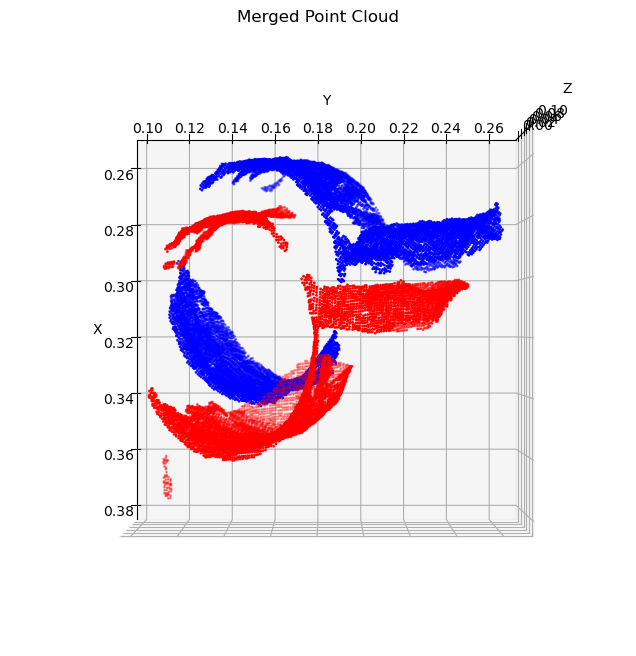

In [71]:
from mpl_toolkits.mplot3d import Axes3D
def visualize_raw_registration_metplotlib(points_collection):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(points_collection[1][:, 0], points_collection[1][:, 1], points_collection[1][:, 2], s=1, c = 'red')  # s=1 for small points
    #ax.scatter(points_collection[4][:, 0], points_collection[4][:, 1], points_collection[4][:, 2], s=1, c = 'grey') 
    ax.scatter(points_collection[3][:, 0], points_collection[3][:, 1], points_collection[3][:, 2], s=1, c = 'blue')  
    #ax.scatter(points_collection[0][:, 0], points_collection[0][:, 1], points_collection[0][:, 2], s=1, c = 'green')
    #ax.scatter(points_collection[7][:, 0], points_collection[7][:, 1], points_collection[7][:, 2], s=1, c = 'yellow')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.title('Merged Point Cloud')
    ax.view_init(elev=90, azim=0)
    plt.show()
    return
visualize_raw_registration_metplotlib(points_collection)

### ICP配准结果

In [67]:
import open3d as o3d
import numpy as np
import copy
def draw_registration_result_matplotlib(source, target, transformation, title = "ICP result", elev = 60, azim = 50 ):
    source_temp = copy.deepcopy(source)
    target_temp = copy.deepcopy(target)
    source_temp.transform(transformation)

    target_points = np.asarray(target_temp.points)
    source_points = np.asarray(source_temp.points)
    
    ## 可视化
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(target_points[:, 0], target_points[:, 1], target_points[:, 2], s=1, c = 'red')  # s=1 for small points
    ax.scatter(source_points[:, 0], source_points[:, 1], source_points[:, 2], s=1, c = 'blue')  

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.title(title)
    ax.view_init(elev, azim)
    plt.show()
    

# source: 2.png
source = o3d.geometry.PointCloud()
source.points = o3d.utility.Vector3dVector(points_collection[1][:, :3])
bc2T = bcT_collection[1]

# target: 4.png
target = o3d.geometry.PointCloud()
target.points = o3d.utility.Vector3dVector(points_collection[3][:, :3])
bc4T = bcT_collection[3]

#### point2point ICP

Apply point-to-point ICP
RegistrationResult with fitness=8.367301e-01, inlier_rmse=2.882390e-03, and correspondence_set size of 11167
Access transformation to get result.
Transformation is:
[[ 0.99986811 -0.01007618 -0.0127371  -0.01563611]
 [ 0.0105541   0.99922089  0.03802921  0.00437985]
 [ 0.01234399 -0.03815862  0.99919545 -0.00320824]
 [ 0.          0.          0.          1.        ]]



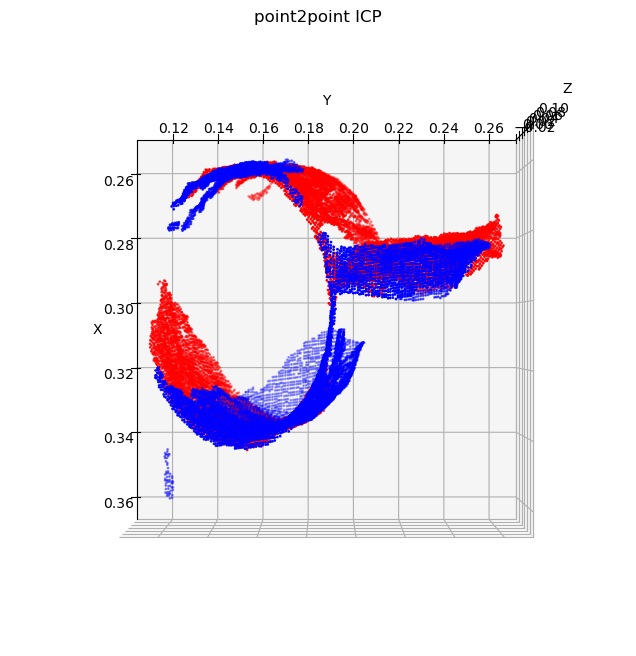

In [70]:
print("Apply point-to-point ICP")
threshold = 0.01

# points_Collection中存放的都是世界坐标系下的单帧点云表示，因此trans_init视作不用变换，单位阵表示

trans_init = np.eye(4)
reg_p2p = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init,
    o3d.pipelines.registration.TransformationEstimationPointToPoint())
print(reg_p2p)
print("Transformation is:")
print(reg_p2p.transformation)
print("")
draw_registration_result_matplotlib(source, target, reg_p2p.transformation, title = 'point2point ICP',elev=90, azim = 0)

#### point2plane ICP

In [6]:
## 需要法线！
reg_p2l = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init,
    o3d.pipelines.registration.TransformationEstimationPointToPlane())
print(reg_p2l)
print("Transformation is:")
print(reg_p2l.transformation)
print("")
draw_registration_result(source, target, reg_p2l.transformation)

RuntimeError: [1;31m[Open3D Error] (virtual std::tuple<std::shared_ptr<const open3d::geometry::PointCloud>, std::shared_ptr<const open3d::geometry::PointCloud> > open3d::pipelines::registration::TransformationEstimationPointToPlane::InitializePointCloudsForTransformation(const open3d::geometry::PointCloud&, const open3d::geometry::PointCloud&, double) const) /home/conda/feedstock_root/build_artifacts/bld/rattler-build_open3d_1776621922/work/cpp/open3d/pipelines/registration/TransformationEstimation.cpp:119: PointToPlaneICP requires target pointcloud to have normals.
[0;m

#### colored ICP